### Test

In [108]:
print("Hello World")

Hello World


## All of the pre-processing

In [109]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler

# 1. Load the Fresh Data
df = pd.read_csv('../../data/messy_ml_data.csv')

print(f"Shape of data before pre-processing : {df.shape}")

# ---------------------------------------------------------
# 2. DROP DUPLICATES (THE SEMANTIC WAY)
# ---------------------------------------------------------
# We check all columns except PassengerId to find identical people
search_cols = df.columns.difference(['PassengerId'])
df = df.drop_duplicates(subset=search_cols, keep='first').reset_index(drop=True)

# 3. Drop Metadata
# (PassengerId is gone now, along with the others)
df = df.drop(['PassengerId', 'Email', 'Phone', 'Remarks', 'JoinDate'], axis=1)

# 4. Standardize Text & Mapping
for col in ['Gender', 'City', 'Subscription', 'IsActive']:
    df[col] = df[col].astype(str).str.strip()

active_map = {'True': 1, '1': 1, '1.0': 1, 'Yes': 1, 'False': 0, '0': 0, '0.0': 0, 'No': 0, 'none': 0, 'nan': 0}
df['IsActive'] = df['IsActive'].map(active_map).fillna(0).astype(int)

gender_map = {
    'F': 'Female',
    'female': 'Female',
    'M': 'Male',
    'male': 'Male'
}
df['Gender'] = df['Gender'].map(gender_map).fillna(df['Gender'])

sub_map = {'FREE': 'Free', 'Free': 'Free', 'NONE': 'Free', 'none': 'Free'
           , 'BASIC': 'Basic', 'Basic': 'Basic', 'PREMIUM': 'Premium', 'Premium': 'Premium'}
df['Subscription'] = df['Subscription'].map(sub_map).fillna('Free')

# 5. Handle All Remaining Nulls
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

for col in ['Age', 'Score', 'Fare']:
    df[col] = df[col].fillna(df[col].median())

df['City'] = df['City'].replace('nan', df['City'].mode()[0])

# ---------------------------------------------------------
# 6. Handle Outliers (Important for clean splitting)
# ---------------------------------------------------------
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] >= (Q1 - 1.5 * IQR)) & (data[column] <= (Q3 + 1.5 * IQR))]

df = remove_outliers(df, 'Age')
df = remove_outliers(df, 'Score')
df = df.reset_index(drop=True)

# 7. Encoding & Scaling
# (We fix the boolean types AND the Fare scaling here)

# Encoding categorical columns
df = pd.get_dummies(df, columns=['Gender', 'City', 'DeptCode', 'DiscountCode', 'IsActive'], drop_first=True)

# Ordinal Encoding for your Target
encoder = OrdinalEncoder(categories=[['Free', 'Basic', 'Premium']])
df['Subscription_Encoded'] = encoder.fit_transform(df[['Subscription']])

# Create the final dataframe and reset index
df_final = df.copy().reset_index(drop=True)

# A. Handle the Fare Scaling (Log + Standardize)
df_final['Fare'] = np.log1p(df_final['Fare'])
df_final[['Fare']] = StandardScaler().fit_transform(df_final[['Fare']])

# B. Scale Age and Score
df_final[['Age']] = MinMaxScaler().fit_transform(df_final[['Age']])
df_final[['Score']] = StandardScaler().fit_transform(df_final[['Score']])

# C. Convert all Boolean columns to 1 and 0 (Universal compatibility)
df_final = df_final.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

print("🚀 Pipeline Complete: Everything is Numeric and Scaled!")
print(f"Shape of data after pre-processing : {df_final.shape}")
df_final.head(3)

Shape of data before pre-processing : (761, 14)
🚀 Pipeline Complete: Everything is Numeric and Scaled!
Shape of data after pre-processing : (749, 16)


,Age,Fare,Subscription,Score,Gender_Male,City_London,City_New York,City_Paris,City_Tokyo,DeptCode_D02,DeptCode_D03,DeptCode_D04,DiscountCode_SAVE20,DiscountCode_WELCOME50,IsActive_1,Subscription_Encoded
0,0.614458,-0.808391,Free,-1.009482,0,0,0,0,1,0,0,1,0,0,1,0.0
1,0.168675,-2.343967,Premium,0.892396,0,1,0,0,0,0,0,1,0,0,0,2.0
2,0.855422,-0.953136,Basic,1.455915,0,0,1,0,0,1,0,0,0,0,0,1.0


# Train test splitting

In [110]:
from sklearn.model_selection import train_test_split
# y is the answer, x is everything else except the original string text
dff = df_final.copy()
y = dff['Subscription_Encoded']
x = dff.drop(['Subscription_Encoded','Subscription'], axis = 1)
print("---Input and output variables created Success! ---")
print(f"Number of input features (x): {x.shape[1]}")
print(f"Shape of (y): {y.shape}")
print(f"Shape of (X): {x.shape}")
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("--- Train and test variables created. Success! ---")
print(f"x_train Size: {x_train.shape}")
print(f"x_test Size: {x_test.shape}")
print(f"y_train Size: {y_train.shape}")
print(f"y_test Size: {y_test.shape}")

---Input and output variables created Success! ---
Number of input features (x): 14
Shape of (y): (749,)
Shape of (X): (749, 14)
--- Train and test variables created. Success! ---
x_train Size: (599, 14)
x_test Size: (150, 14)
y_train Size: (599,)
y_test Size: (150,)


# Feature Selection

## 🛑 Feature Selection Step 1: Variance & Constants - Theory

The most fundamental step in feature selection is identifying columns that provide **no information** because they simply don't change.

---

### 1. The Core Concept: Variance
**Variance** is a mathematical measure of how "spread out" your data is.
*   **High Variance**: The data changes a lot (e.g., Age ranges from 18 to 80).
*   **Zero Variance**: The data is exactly the same for every row (e.g., every row has "Tokyo").

### Why do we drop Zero Variance columns?
Machine learning models learn by looking at **differences**. If a column never differences, the model can't use it to predict why one customer is "Basic" and another is "Premium."

---

### 2. Types of "Dead Weight"

#### A. Constant Features
*   **Definition**: 100% of the rows have the same value.
*   **Example**: A column `Country` where every single person is from "India."
*   **Action**: **Drop Immediately.**

#### B. Quasi-Constant Features
*   **Definition**: Almost all rows (e.g., 99%) have the same value.
*   **Example**: A column `Is_Robot` where 9,999 rows are `0` and only 1 row is `1`.
*   **Danger**: This 1 outlier is not enough for the model to learn a pattern. It actually becomes "noise" that might cause the model to make mistakes.
*   **Action**: **Drop if above a threshold** (usually 99% or 95%).

---

### 3. The "Identical Twins" Analogy
Imagine you are trying to tell two identical twins apart:
1.  **Eye Color**: Both have Green eyes. This is a **Constant Feature**. It is useless for identification.
2.  **Birthmark**: Only one has a small birthmark on their left arm. This is a **High Variance** feature. It is your key "Signal" to telling them apart.

---

### 4. When to do this?
> [!IMPORTANT]
> **Order Matters**: Always remove constant features **after** you have handled missing values, because a column might look constant only because it's full of `NaN`s!

---

### 5. Summary
*   **Signal**: Data that changes and helps us predict.
*   **Noise/Dead Weight**: Data that stays the same and confuses the model.
*   **Rule**: If it doesn't vary, it doesn't carry (information).

---

### 6. Practical Implementation

There are two ways to handle this: the **Manual** way (best for exploration) and the **Automated** way (best for pipelines).

#### Option 1: The Manual Way (The "Sanity Check")
Use this to see exactly *which* columns are causing the problem.

```python
# 1. Count unique values in each column
unique_counts = x_train.nunique()

# 2. Identify columns with only 1 unique value (Constant)
constant_cols = unique_counts[unique_counts == 1].index.tolist()

print(f"Constant columns found: {constant_cols}")

# 3. Drop them manually if you found any
x_train_manual = x_train.drop(columns=constant_cols)
x_test_manual = x_test.drop(columns=constant_cols)
```

#### Option 2: The Automated Way (The "Pro Pipeline")
Use this for clean, reproducible production code using Scikit-Learn.

```python
from sklearn.feature_selection import VarianceThreshold

# 1. Initialize (threshold=0 means drop only perfect constants)
selector = VarianceThreshold(threshold=0)

# 2. FIT on the training data ONLY (The 'No Peeking' rule)
selector.fit(x_train)

# 3. Identify the columns to keep
# selector.get_support() returns a list of True/False for each column
features_to_keep = x_train.columns[selector.get_support()]

# 4. Filter both train and test to keep only the 'Signal'
x_train_fs1 = x_train[features_to_keep]
x_test_fs1 = x_test[features_to_keep]

# 5. Review the results
print(f"Original feature count: {x_train.shape[1]}")
print(f"Features removed: {x_train.shape[1] - x_train_fs1.shape[1]}")
print(f"New feature count: {x_train_fs1.shape[1]}")

### Doing Practical now

#### The Manual Way (The "Sanity Check") to check variance and constant columns

In [111]:
# 1. Count unique values in each column
unique_counts = x_train.nunique()
unique_counts

Age                        84
Fare                      576
Score                      70
Gender_Male                 2
City_London                 2
City_New York               2
City_Paris                  2
City_Tokyo                  2
DeptCode_D02                2
DeptCode_D03                2
DeptCode_D04                2
DiscountCode_SAVE20         2
DiscountCode_WELCOME50      2
IsActive_1                  2
dtype: int64

In [112]:
# 2. Identify columns with only 1 unique value (Constant)
constant_cols = unique_counts[unique_counts == 1].index.tolist()
print(f"Constant columns found: {constant_cols}")

Constant columns found: []


In [113]:
# 3. Drop them manually if you found any
x_train_manual = x_train.drop(columns=constant_cols)
x_test_manual = x_test.drop(columns=constant_cols)

#### Option 2: The Automated Way (The "Pro Pipeline")

In [114]:
from sklearn.feature_selection import VarianceThreshold

In [115]:
# 1. Initialize (threshold=0 means drop only perfect constants)
selector = VarianceThreshold(threshold=0)
# 2. Fit and Learn from ONLY the training data
selector.fit(x_train)
features_to_keep = x_train.columns[selector.get_support()]
x_train_fs1 = x_train[features_to_keep]
x_test_fs1 = x_test[features_to_keep]
print(f"Features removed: {x_train.shape[1] - x_train_fs1.shape[1]}")

Features removed: 0


## 👯 Feature Selection Step 1.5: Duplicate Features

Before moving to the statistical math of correlation, we must ensure there aren't any **identical "twin" columns** hiding in our data under different names.

---

### 1. The Concept: Identical Twins
A **Duplicate Feature** occurs when two columns have the exact same values for every single row in the training set.

*   **Why it happens**: Poorly planned One-Hot encoding, merging multiple datasets with overlapping information, or simple manual error.
*   **The Problem**: It adds zero value to the model but doubles the memory usage and can cause mathematical instability in some models.
*   **The Action**: Find them and keep only one.

---

### 2. Difference between Variance, Duplicates, and Correlation

| Step | Goal | Analogy |
| :--- | :--- | :--- |
| **Step 1: Variance** | Find columns that don't change. | A light that is always "off." |
| **Step 1.5: Duplicates** | Find different columns that are identical. | Two lights connected to the same switch. |
| **Step 2: Correlation** | Find columns that are very similar. | A light and a dimmer—they do similar things. |

---

### 3. Practical Implementation

Since we are looking for identical columns, we can't just use `drop_duplicates()` (which looks at rows). We have to **Transpose** the data (flip rows and columns) so that columns become rows, and then we check for duplicates.

#### The Automated Way
We analyze the columns in the training set, identify which ones are unique, and then subset both sets.

```python
# 1. Transpose the data (Flipping columns to rows)
# We use .T to flip it
x_train_T = x_train_fs1.T

# 2. Find duplicate Rows (which were our columns!)
# .duplicated() will return True for the second twin
duplicated_feat_mask = x_train_T.duplicated()

# 3. Get the list of column names to DROP
features_to_drop = x_train_T[duplicated_feat_mask].index.values

print(f"Duplicate columns found: {features_to_drop}")

# 4. Filter both sets
x_train_fs1_5 = x_train_fs1.drop(columns=features_to_drop)
x_test_fs1_5 = x_test_fs1.drop(columns=features_to_drop)

print(f"Final feature count: {x_train_fs1_5.shape[1]}")
```

---

### 4. Why ONLY on X_train?
> [!IMPORTANT]
> Just like Variance and Scaling, we decide which columns are duplicates based **ONLY on the Training set**. We then apply that same "Drop List" to the Testing set to keep them synchronized.


### Doing Practical now

In [116]:
# 1. Transpose the data (Flipping columns to rows)
# We use .T to flip it
x_train_T = x_train_fs1.T

# 2. Find duplicate Rows (which were our columns!)
# .duplicated() will return True for the second twin
duplicated_feat_mask = x_train_T.duplicated()

# 3. Get the list of column names to DROP
features_to_drop = x_train_T[duplicated_feat_mask].index.values

print(f"Duplicate columns found: {features_to_drop}")

# 4. Filter both sets
x_train_fs1_5 = x_train_fs1.drop(columns=features_to_drop)
x_test_fs1_5 = x_test_fs1.drop(columns=features_to_drop)

print(f"Final feature count: {x_train_fs1_5.shape[1]}")

Duplicate columns found: <StringArray>
[]
Length: 0, dtype: str
Final feature count: 14


## 🔗 Feature Selection Step 2: Correlation Analysis (Multi-collinearity)

Now that we've removed columns that don't change or are exact duplicates, we need to find features that are **redundant**—meaning they tell almost the exact same story as another feature.

---

### 1. The Behind-the-Scenes: The Math of $r$
The number you see in a correlation matrix (between -1.0 and 1.0) is called the **Pearson Correlation Coefficient**.

#### The Formula
$$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2} \sqrt{\sum (y_i - \bar{y})^2}} $$

#### The Intuition
*   **Numerator (Top)**: Measures **Covariance** (How much X and Y move **together**). If they both jump up at the same time, this number becomes positive.
*   **Denominator (Bottom)**: Measures **Total Spread** (How much they jump around on their own).
*   **The Result**: By dividing "Shared Movement" by "Total Movement," we "squeeze" the result into a fixed window of **-1.0 to 1.0** regardless of the scale of your data.

---

### 2. The Concept: Multi-collinearity
**Multi-collinearity** occurs when two or more independent features are highly correlated with each other.

*   **The Problem**: If two features (like `Height_in_Inches` and `Height_in_CM`) are 100% correlated, the model doesn't know which one to "blame" for the prediction. This makes the model's coefficients unstable and hard to interpret.
*   **The Goal**: Maintain a lean dataset where every feature provides **unique** information.

---

### 2. The Pearson Correlation Coefficient ($r$)
We use a value between **-1.0** and **1.0** to measure the relationship:
*   **1.0**: Perfect Positive Correlation (They move identical directions).
*   **-1.0**: Perfect Negative Correlation (They move in exactly opposite directions).
*   **0.0**: No relationship at all.

**The Threshold**: In professional ML, we usually look for correlations above **0.85 or 0.90**. If two features are that close, we drop one of them.

---

### 3. Practical Implementation: The Heatmap
The best way to "see" correlation is a **Heatmap**. This is a visual grid where the numbers are replaced by colors so you can spot the "Red Zones" (high correlation) at a glance.

```python
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Correlation Matrix
# .corr() calculates the Pearson correlation coefficient between every pair of columns.
# It returns a square table where both the rows and columns are your feature names.
# A '1.0' on the diagonal means every column is 100% correlated with itself!
corrmat = x_train_fs1_5.corr()

# 2. Plot the Heatmap
# plt.figure sets the size of the drawing 'canvas' so the labels aren't cramped.
plt.figure(figsize=(12,10))

# sns.heatmap creates the visual grid.
# annot=True: This writes the actual correlation number inside each square.
# cmap='RdYlGn': This sets the color palette to Red-Yellow-Green.
# Green = Positive correlation, Red = Negative correlation.
# fmt=".2f": This rounds the displayed numbers to 2 decimal places.
sns.heatmap(corrmat, annot=True, cmap='RdYlGn', fmt=".2f")

# plt.show() actually renders the image in your notebook.
plt.show()
```

---

### 4. The Automated Removal Script
Doing this manually for 50 columns is impossible. We use a script to find columns that are too similar and mark them for deletion.

```python
# Definition of a custom function to find highly correlated features
def correlation_filter(data, threshold):
    # We use a set() to store column names we want to drop.
    # A set is better than a list because it automatically prevents duplicate names.
    col_corr = set() 
    
    # Generate the correlation matrix again inside the function
    corr_matrix = data.corr()
    
    # We use a 'Nested Loop' (a loop inside a loop) to compare every column to every other column.
    # i represents the current row in the matrix, j represents the current column.
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            # We only look at the 'Lower Triangle' of the matrix (where j < i).
            # Why? Because the matrix is symmetrical. Correlation(A,B) is the same as Correlation(B,A).
            # Checking both would be redundant and waste time.
            
            # abs() calculates the Absolute Value. 
            # We care about -0.9 just as much as +0.9 because both mean redundancy!
            if abs(corr_matrix.iloc[i, j]) > threshold:
                
                # If the correlation is higher than our limit (e.g. 0.85),
                # we grab the name of that column and add it to our drop set.
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
                
    return col_corr

# 1. Run the filter with a 0.85 threshold.
# This means if two columns are 85% similar, we will drop one of them.
to_drop = correlation_filter(x_train_fs1_5, 0.85)

# 2. Print the results so you can see if anything was found
print(f"Redundant columns to drop: {to_drop}")

# 3. Drop the redundant columns from both Train and Test sets
# This creates our Step 2 version of the variables (_fs2)
x_train_fs2 = x_train_fs1_5.drop(columns=to_drop)
x_test_fs2 = x_test_fs1_5.drop(columns=to_drop)

print(f"Final feature count after redundancy check: {x_train_fs2.shape[1]}")
```

---

### 5. Why ONLY on X_train?
> [!IMPORTANT]
> This is a statistical measurement. Your "Testing Set" might have weird, accidental correlations because it is small. We only trust the patterns found in the **Training Set**.


### Doing practical now

#### Manual inspection

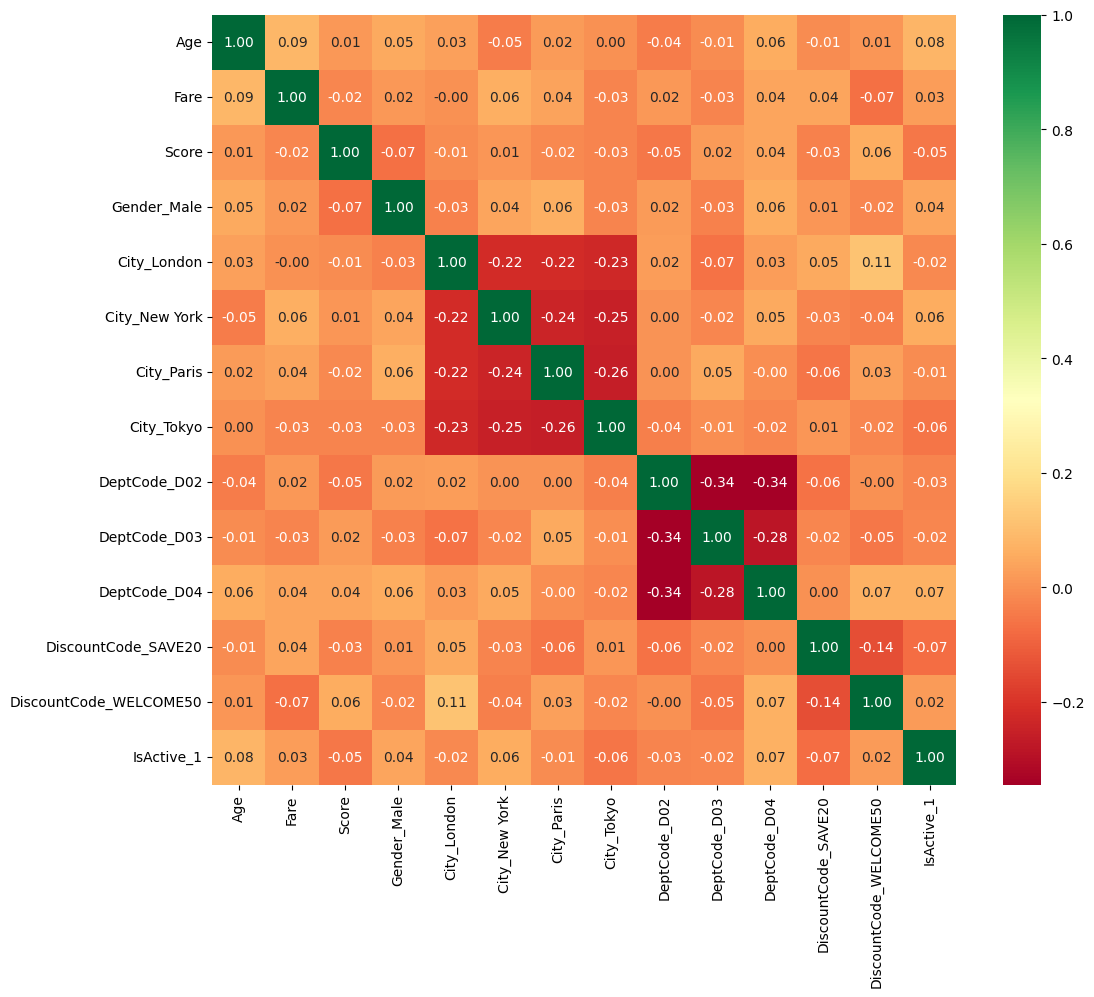

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Correlation Matrix
# This calculates the 'Pearson' relationship between every column.
# A 1.0 means perfectly identical; a 0.0 means no relationship at all.
corrmat = x_train_fs1_5.corr()

# 2. Plot the Heatmap
# figsize=(12,10) makes the image large enough to read the column names.
plt.figure(figsize=(12,10))

# annot=True: Writes the number inside the cell.
# cmap='RdYlGn': Red (negative), Yellow (neutral), Green (positive).
# fmt=".2f": Rounds the numbers to 2 decimal places.
sns.heatmap(corrmat, annot=True, cmap='RdYlGn', fmt=".2f")
plt.show()

#### Automated filtering out highly correlated columns/features

In [118]:
def correlation_filter(data, threshold):
    # A set() automatically prevents us from adding the same column name twice
    col_corr = set() 
    corr_matrix = data.corr()
    
    # We use a nested loop (i and j) to scan the matrix.
    # We only look at the 'lower triangle' (j < i) because the matrix is a mirror image.
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            # abs() catches both positive and negative redundancy.
            if abs(corr_matrix.iloc[i, j]) > threshold:
                col_corr.add(corr_matrix.columns[i])
    return col_corr


# Let's drop anything with a correlation higher than 0.85
to_drop = correlation_filter(x_train_fs1_5, 0.85)
print(f"Dropping these redundant columns: {to_drop}")

# Filter both sets
x_train_fs2 = x_train_fs1_5.drop(columns=to_drop)
x_test_fs2 = x_test_fs1_5.drop(columns=to_drop)

Dropping these redundant columns: set()


##### Rough work to understand above code and loop

In [119]:
correlation_filter(x_train_fs1_5, 0.8)

set()

In [120]:
corrmat.iloc[1,0].round(2).item()

0.09

In [121]:
corrmat.columns[1]

'Fare'

In [122]:
i=0
j=0
for i in range(14):
    # print(f" Ou i:{i} j:{j}", end="")
    for j in range(i):
        # print(f" I i:{i} j:{j}", end="")
        # print(corrmat.iloc[i,j].round(2).item() , end="")
        if(corrmat.iloc[i,j].round(2).item()>0.8):
            print(1, end='')
        print(0, end='')
    print()


0
00
000
0000
00000
000000
0000000
00000000
000000000
0000000000
00000000000
000000000000
0000000000000


#### Example of finding collinearity between age and fare using code instead of the collinearity function by using the statistical formula 

In [123]:
import numpy as np

# 1. Define our two columns from your x_train variable
x = x_train['Age']
y = x_train['Fare']

# 2. Calculate the means (the 'bar' in the formula)
x_mean = x.mean()
y_mean = y.mean()

# 3. Calculate the Numerator (How they move together)
# Sum of (x_i - x_mean) * (y_i - y_mean)
numerator = np.sum((x - x_mean) * (y - y_mean))

# 4. Calculate the Denominator (Their individual spreads)
# Step A: Sum of squares for x
x_spread = np.sum((x - x_mean)**2)
# Step B: Sum of squares for y
y_spread = np.sum((y - y_mean)**2)

denominator = np.sqrt(x_spread * y_spread)

# 5. Calculate final r
r_manual = numerator / denominator

# 6. Compare with the Pandas built-in result
r_pandas = x.corr(y)

print(f"Manual Calculation (Formula): {r_manual:.6f}")
print(f"Pandas Built-in (.corr()):   {r_pandas:.6f}")


Manual Calculation (Formula): 0.085226
Pandas Built-in (.corr()):   0.085226


## 🧠 Feature Selection Step 3: Mutual Information (Relevance)

After removing dead weight and redundancy, we now need to find which features actually "care" about the target variable. We use **Mutual Information** to rank features by their importance.

---

### 1. The Concept: Information Gain
**Mutual Information (MI)** measures the "dependency" between two variables. It asks: *"If I know the value of this feature, how much does my uncertainty about the target decrease?"*

*   **Higher Value**: Significant relationship. The feature is a strong "signal."
*   **0.0 Value**: No relationship. The feature is complete "noise" for this specific target.

### 2. Why Mutual Information?
Unlike the Correlation we did in Step 2, Mutual Information can capture **Non-Linear** relationships.
*   **Correlation**: Only sees straight lines.
*   **MI**: Sees complex patterns, curves, and clusters.

---

### 3. The "Ingredient" Analogy
Imagine you are making a specific dish (the target).
1.  **Step 1 & 2** were about throwing away rotten food (constants) and extra packs of the same spice (duplicates).
2.  **Step 3** is about tasting every remaining ingredient to see if it actually belongs in this specific dish. (A battery is unique and well-made, but it has **Zero Mutual Information** with a good soup!)

---

### 4. Practical Implementation

We use `mutual_info_classif` because our target (`Subscription`) is a classification problem.

```python
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate the Mutual Information
# We use x_train_fs2 (the output from our last correlation step)
# random_state is used because the algorithm has a stochastic (random) element
mutual_info = mutual_info_classif(x_train_fs2, y_train, random_state=42)

# 2. Map the results back to the column names
# We create a Series where the index is our Feature Names
mi_series = pd.Series(mutual_info, index=x_train_fs2.columns)

# 3. Sort for Plotting
# For horizontal bars (barh), Matplotlib plots from the bottom up.
# To get the highest score at the TOP, we sort ascending here.
mi_plot_data = mi_series.sort_values(ascending=True)

# 4. Plotting the 'Signal'
plt.figure(figsize=(10, 8))
# barh creates a horizontal bar chart
mi_plot_data.plot(kind='barh', color='teal')
plt.title("Step 3: Feature Relevance Ranking (Highest at Top)")
plt.xlabel("Mutual Information Score")
plt.show()

# 5. Review the 'Top Candidates'
# We still print the head of the original descending series to see the top 10
print("🏆 The High-Signal Features:")
print(mi_series.head(10))
```

---

### 5. Why ONLY on X_train?
> [!IMPORTANT]
> Just like all selection steps, we calculate relevance based **only on the training data**. We do not want the test set to influence which features we choose to keep.

In [124]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate the Mutual Information
# We use x_train_fs2 (the output from our last correlation step)
# random_state is used because the algorithm has a stochastic (random) element
mutual_info = mutual_info_classif(x_train_fs2, y_train, random_state=42)
mutual_info

array([0.03199309, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.04443131, 0.00228352, 0.00901609, 0.        ,
       0.00419494, 0.01162812, 0.00817047, 0.04238257])

In [125]:
# 2. Create a Series for easy viewing
mi_series = pd.Series(mutual_info, index=x_train_fs2.columns)
mi_series

Age                       0.031993
Fare                      0.000000
Score                     0.000000
Gender_Male               0.000000
City_London               0.000000
City_New York             0.000000
City_Paris                0.044431
City_Tokyo                0.002284
DeptCode_D02              0.009016
DeptCode_D03              0.000000
DeptCode_D04              0.004195
DiscountCode_SAVE20       0.011628
DiscountCode_WELCOME50    0.008170
IsActive_1                0.042383
dtype: float64

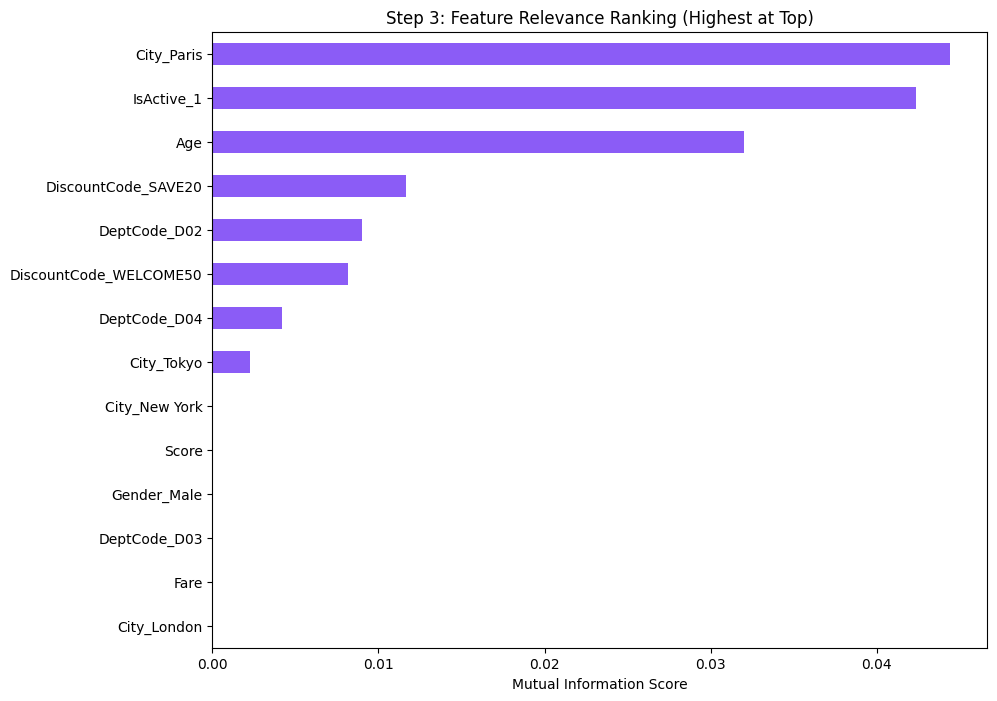

🏆 The High-Signal Features:
City_Paris             0.044431
IsActive_1             0.042383
Age                    0.031993
DiscountCode_SAVE20    0.011628
DeptCode_D02           0.009016
dtype: float64


🏆 All Features:
City_Paris                0.044431
IsActive_1                0.042383
Age                       0.031993
DiscountCode_SAVE20       0.011628
DeptCode_D02              0.009016
DiscountCode_WELCOME50    0.008170
DeptCode_D04              0.004195
City_Tokyo                0.002284
City_New York             0.000000
Score                     0.000000
Fare                      0.000000
City_London               0.000000
Gender_Male               0.000000
DeptCode_D03              0.000000
dtype: float64


In [146]:
# 3. Sort for Plotting
# For horizontal bars (barh), Matplotlib plots from the bottom up.
# To get the highest score at the TOP, we sort ascending here.
mi_plot_data = mi_series.sort_values(ascending=True)

# 4. Plotting the 'Signal'
plt.figure(figsize=(10, 8))
# barh creates a horizontal bar chart
mi_plot_data.plot(kind='barh', color='#8B5CF6')
plt.title("Step 3: Feature Relevance Ranking (Highest at Top)")
plt.xlabel("Mutual Information Score")
plt.show()

# 5. Review the 'Top Candidates'
# We still print the head of the original descending series to see the top 10
mi_series = mi_series.sort_values(ascending=False)
print("🏆 The High-Signal Features:")
print(mi_series.head(5))

print("\n\n🏆 All Features:")
print(mi_series)

## 🎯 Feature Selection Step 4: Statistical Selection (SelectKBest)

Now that we have ranked our features by relevance (Mutual Information), we need a systematic way to **filter** the data and "hire" only the top-performing features while letting go of the noise.

---

### 1. The Concept: SelectKBest
**SelectKBest** is a Scikit-Learn utility that automatically selects the top '$k$' features according to a scoring function.

*   **The Input**: Your full feature set and your target.
*   **The Scoring Function**: Our Mutual Information (MI) score from Step 3.
*   **The Threshold ($k$)**: A fixed number of features you want to keep.

---

### 2. Why use a Selector?
Instead of manually dropping columns one by one (which is prone to errors), a **Selector** provides:
1.  **Reproducibility**: You can log exactly how many features you kept.
2.  **Pipeline Integration**: You can eventually put this selector inside a Scikit-Learn `Pipeline`.
3.  **Efficiency**: It handles the boolean masking for you automatically.

---

### 3. Practical Implementation

We will set $k=8$ as an example, but you can change this number based on how many "Noise" (0.00) features you found in your results.

```python
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 1. Initialize the Selector
# k=8: Change this number if you want to keep more or fewer features
# score_func: We stick with mutual_info_classif for non-linear detection
selector = SelectKBest(score_func=mutual_info_classif, k=8)

# 2. Fit and Learn
# This learns which columns are the best based on x_train and y_train
selector.fit(x_train_fs2, y_train)

# 3. Get the Mask of winning features
# .get_support() returns a list of Booleans [True, False, True...]
feature_mask = selector.get_support()

# 4. Map the mask back to the column names
winning_columns = x_train_fs2.columns[feature_mask]

# 5. Transform the data
# We use indexing to filter both the Train and Test sets
x_train_fs3 = x_train_fs2[winning_columns]
x_test_fs3 = x_test_fs2[winning_columns]

print(f"✅ Success! You have 'hired' the top {len(winning_columns)} features.")
print(f"Final List: {winning_columns.tolist()}")
```

---

### 4. How to choose the value of 'K'?
> [!TIP]
> Look at your Mutual Information chart from Step 3.
> *   If you have 5 features with high scores and 15 with nearly zero scores, set $k=5$.
---

### 5. Why not just delete the columns manually?
You might be wondering: *"If I see 0.00 scores, why can't I just use `df.drop()`?"*

While manual dropping works for small projects, **SelectKBest** is used in professional workflows for three reasons:

1.  **Scale**: If you have 20,000 features, you cannot find the winners by eye. A function does it in milliseconds.
2.  **Automation (Pipelines)**: When you put your model into production, you need an automated process. You can't have a human manually deleting columns every time a new customer signs up!
3.  **Human Error**: Manual typing leads to typos (misspelling a column name). A function uses mathematical logic, which is 100% consistent.

You could just manually type df.drop(columns=['Fare', 'Score', ...]). For a small dataset like ours, it would work perfectly.

However, in professional Machine Learning, we use the SelectKBest function for three "Big Picture" reasons:

1. The "Scale" Problem 🏋️
Imagine you are working on a genomic dataset with 20,000 features.

Manual: You would have to read through 20,000 numbers, find the zeros, and type their names one by one. You would be typing for days!
The Function: It finds those 20,000 winners in 0.2 seconds.
2. The "Pipeline" (Automation) 🤖
When you finish your notebook, you don't want to just have a static model. You want to "deploy" it so it can process new data every day.

Manual: Every time new data comes in, a human has to sit there and delete columns.
The Function: It becomes a "Step" in an automated assembly line. New data goes in → The selector automatically crops it → The model predicts. No human needed.
3. Avoiding "Human Fingerprints" ✍️
If you manually delete columns, you might accidentally delete City_Tokyo because you misread the decimal point.

The Function: It uses cold, hard logic. If you tell it "Give me the Top 10," it will mathematically find the Top 10 without any typos or accidental skips.
🍱 The Takeaway
In this small practice dataset, manual is fine. But learning the Function is like learning to use a power tool. You don't need a chainsaw to cut a pencil, but you definitely want to know how to use one before you have to clear a forest!

> [!NOTE]
> Learning the **Function** is like learning to use a power tool. You don't need a chainsaw to cut a pencil, but you'll be glad you know how to use one when you have to clear a whole forest of data!


### 6. Feature Selection Strategy: How to choose 'K'?

Choosing the number of features ($k$) is one of the most critical decisions in feature engineering. If you pick too few, you lose information. If you pick too many, you keep the noise.

---

#### 1. The Statistical Strategy: The "Zero-Filter"
This is the most straightforward approach. You look at your Mutual Information scores and find where the "Information Signal" dies.

*   **Your Data**: You found 6 features with actual scores (`0.002` to `0.044`) and 7 features with a score of exactly `0.000000`.
*   **The Decision**: In this case, $k=8$ is the logical choice because it keeps every feature that has **any** detectable relationship with the target while cutting out the absolute zeros.

---

#### 2. The Visual Strategy: The "Elbow Method" (Scree Plot)
Just like in clustering, you can plot your scores in descending order and look for the **"Elbow"** (the sharp drop-off).

*   **Top Group**: `City_Paris`, `IsActive_1`, `Age` (Scores > 0.03).
*   **Middle Group**: `DiscountCode`, `DeptCode` (Scores 0.008 - 0.01).
*   **Bottom Group**: Absolute zeros.
*   **Strategy**: You select $k$ so it captures the big drops. You would likely pick $k=3$ (Top Signal) or $k=8$ (Including Secondary Signal).

---

#### 3. The Automated Way: `SelectPercentile`
Sometimes, instead of picking a hard number like "10 features," you want to say "Give me the Top 50% of columns." This makes your code more flexible if you add more columns later.

```python
from sklearn.feature_selection import SelectPercentile, mutual_info_classif

# This automatically calculates k based on the percentage you want
# percentile=50 will keep the top half of your features
selector = SelectPercentile(score_func=mutual_info_classif, percentile=50)
selector.fit(x_train_fs2, y_train)

# Filter the data
x_train_p = x_train_fs2.iloc[:, selector.get_support()]
```

---

#### 4. The "Pro" Way: Hyperparameter Tuning (Grid Search)
In real-world production, we don't guess $k$. We let the computer guess and check the results using **GridSearchCV**.

1.  The computer tries $k=2$. It trains a model and checks the accuracy.
2.  It tries $k=5$. It checks the accuracy.
3.  It tries $k=10$. It checks the accuracy.
4.  **The Result**: It tells you: *"Accuracy was highest when k was 8."*

---

#### 5. Summary Thinking Table

| Method | When to use it? | Reliability |
| :--- | :--- | :--- |
| **Zero-Filter** | When half your data is clearly junk. | High (for cleanup) |
| **Visual Elbow** | When you have a clear "leader" group. | Medium |
| **Percentile** | When your total column count changes. | Medium |
| **Grid Search** | When you are chasing maximum accuracy. | Best |

> [!TIP]
> **My recommendation for your current dataset**: Start with $k=8$ (Zero-Filter). It removes the 100% useless noise but keeps the subtle hints from the smaller categories like `City_Tokyo`.


### Doing practical now

In [144]:
from sklearn.feature_selection import SelectKBest
# 1. Initialize the Selector
# k=10 means 'Pick the top 10 features based on the score'
# score_func=mutual_info_classif tells it to use the scoring method we just learned
selector = SelectKBest(score_func=mutual_info_classif, k=8)
# 2. Fit and Learn from the training data ONLY
selector.fit(x_train_fs2, y_train)
# 3. Get the names of the winning features
# get_support() returns a list of True/False for each column
cols_to_keep = x_train_fs2.columns[selector.get_support()]
# 4. Filter your dataframes to only keep the 'Winners'
x_train_fs3 = x_train_fs2[cols_to_keep]
x_test_fs3 = x_test_fs2[cols_to_keep]
print(f"✅ We successfully removed the noise!")
print(f"Features remaining: {len(cols_to_keep)}")
print(f"Selected: {cols_to_keep.tolist()}")

✅ We successfully removed the noise!
Features remaining: 8
Selected: ['Age', 'Score', 'Gender_Male', 'City_New York', 'DeptCode_D02', 'DeptCode_D03', 'DeptCode_D04', 'IsActive_1']


## 🔄 Feature Selection Step 5: Recursive Feature Elimination (RFE)

We have now moved past "Filter" methods (which look only at statistics) and into **"Wrapper"** methods. In this step, we actually use a Machine Learning model to decide which features are the most powerful.

---

### 1. The Concept: Recursive Elimination
**RFE** works by process of elimination:
1.  It trains a model on **all** current features.
2.  It calculates the "Importance" of each feature.
3.  It removes the **least important** feature.
4.  It repeats the process (re-training the model every time) until it reaches the number of features you requested.

*   **Why it's better**: It looks at how features work **together** within a specific model logic.
*   **The Cost**: It is much slower than filters because it has to train a model many times.

---

### 2. The "Lead Detective" Analogy
Imagine a coach picking a basketball team:
*   **Filter Methods (Steps 1-4)**: The coach looks at stats (Height, Weight, Points per game) and cuts the bottom players.
*   **Wrapper Methods (Step 5)**: The coach actually watches the players **play a game** together. He removes the person who doesn't fit the team vibe, then watches again. He keeps doing this until only the "Elite 5" are on the court.

---

### 3. Understanding the "Teacher" Parameters
In the code below, we use `n_estimators=100`. 
*   **What it means**: This is the number of **Decision Trees** in the "Forest."
*   **The Analogy**: Imagine asking 100 different people (trees) to vote on the best features. If 1 person is biased, it doesn't matter, because the other 99 will balance them out.
*   **The Trade-off**: More trees mean a more stable and accurate ranking, but the calculation will take longer. `100` is the industry standard "sweet spot."

---

### 4. Practical Implementation

We will use a **Random Forest** as the "Judge" because it is very robust and can handle complex relationships.

```python
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the 'Teacher' Model
# This is the model that will judge the features. 
# We use Random Forest because it gives us clear 'Feature Importances'.
teacher = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Initialize the RFE Wrapper
# n_features_to_select=5: The number of 'Elite' players we want to keep.
# step=1: Remove 1 feature at a time in each round.
rfe = RFE(estimator=teacher, n_features_to_select=5, step=1)

# 3. Fit the wrapper (using x_train_fs3 from the last step)
# This might take a few seconds because it is training models repeatedly!
rfe.fit(x_train_fs3, y_train)

# 4. Identify the winners
# .support_ is a boolean mask (True for winners)
winning_mask = rfe.support_
winning_features = x_train_fs3.columns[winning_mask]

# 5. Transform your data for the final time!
x_train_final = x_train_fs3[winning_features]
x_test_final = x_test_fs3[winning_features]

print(f"🎖️ The Final Elite Feature Team: {winning_features.tolist()}")
```

---

### 4. Ranking vs. Filtering
> [!NOTE]
> Unlike `SelectKBest` which gives you a score (like 0.04), RFE gives you a **Ranking**.
> You can check `rfe.ranking_` to see the order of elimination. A ranking of `1` means the feature was part of the final winning team.


### Trying it out - Practical

In [145]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the 'Teacher' Model
# This is the model that will judge the features. 
# We use Random Forest because it gives us clear 'Feature Importances'.
teacher = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Initialize the RFE Wrapper
# n_features_to_select=5: The number of 'Elite' players we want to keep.
# step=1: Remove 1 feature at a time in each round.
rfe = RFE(estimator=teacher, n_features_to_select=5, step=1)

# 3. Fit the wrapper (using x_train_fs3 from the last step)
# This might take a few seconds because it is training models repeatedly!
rfe.fit(x_train_fs3, y_train)

# 4. Identify the winners
# .support_ is a boolean mask (True for winners)
winning_mask = rfe.support_
winning_features = x_train_fs3.columns[winning_mask]

# 5. Transform your data for the final time!
x_train_final = x_train_fs3[winning_features]
x_test_final = x_test_fs3[winning_features]

print(f"🎖️ The Final Elite Feature Team: {winning_features.tolist()}")

🎖️ The Final Elite Feature Team: ['Age', 'Score', 'Gender_Male', 'City_New York', 'DeptCode_D02']


## 🤖 Feature Selection Step 6: Automated RFE (RFECV)

We've seen that manually picking $k$ (the number of features) is a bit of a guessing game. **RFECV** (Recursive Feature Elimination with Cross-Validation) solves this by using a "brute-force" search to find the mathematically optimal number of features.

---

### 1. The Concept: Automatic Search
RFECV performs the following loop:
1.  Try a model with **all** features. Measure the score (e.g., Accuracy).
2.  Remove the weakest feature. Measure the score **again**.
3.  ...Repeat until only 1 feature remains.
4.  **The Result**: It looks at all those scores and picks the **highest peak**.

---

### 2. The Accuracy Curve
When you run RFECV, you can plot the results. 
*   **The Rise**: As you add important features, accuracy goes up.
*   **The Peak**: The "Sweet Spot" (this is your $k$).
*   **The Fall**: If you add too many noise features, accuracy starts to drop. RFECV stops you right at the peak.

---

### 3. Practical Implementation

```python
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Initialize the Teacher Model
teacher = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Initialize RFECV
# cv=5: It splits the data 5 times to cross-verify the score.
# min_features_to_select=1: Let it explore everything down to just 1 feature.
rfecv = RFECV(estimator=teacher, step=1, cv=5, scoring='accuracy')

# 3. Fit (Learn the optimal K)
rfecv.fit(x_train_fs3, y_train)

# 4. Extract the 'Chosen' K
optimal_k = rfecv.n_features_
print(f"✅ The Machine has decided! The optimal K is: {optimal_k}")

# 5. Transform the data
winning_features = x_train_fs3.columns[rfecv.support_]
x_train_final = x_train_fs3[winning_features]
x_test_final = x_test_fs3[winning_features]
```

---

### 4. RFECV vs. RFE: When to use which?

| Feature | RFE | RFECV |
| :--- | :--- | :--- |
| **How K is chosen?** | Manually (Guessing). | Automatically (Optimized). |
| **Speed** | Fast. | Slower (Trains many models). |
| **Best For?** | Quick experiments / Learning. | Production Pipelines / Final Models. |

> [!IMPORTANT]
> RFECV is the **gold standard** for professional machine learning. If you have the time and computing power, always let RFECV find the $k$ for you.


✅ The Machine has decided! The optimal K is: 8


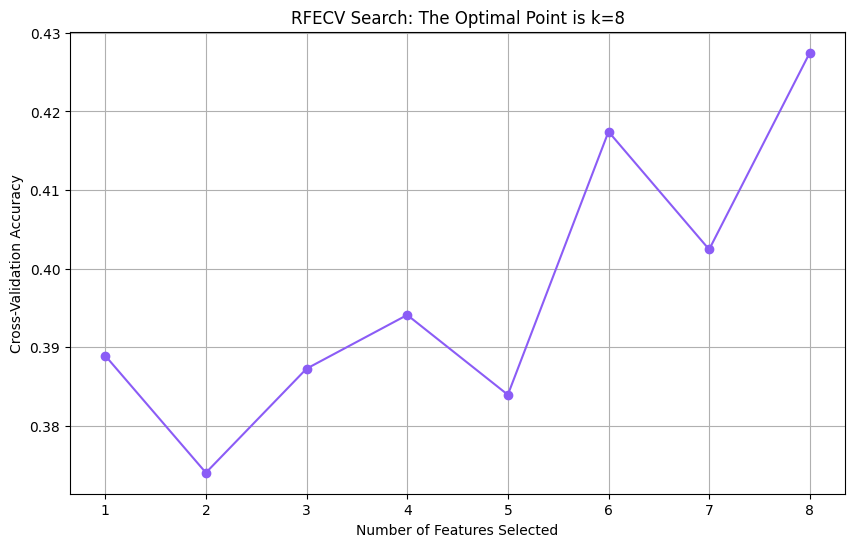

🎖️ The Final Elite Feature Team: ['Age', 'Score', 'Gender_Male', 'City_New York', 'DeptCode_D02', 'DeptCode_D03', 'DeptCode_D04', 'IsActive_1']


In [153]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Initialize the Teacher Model
teacher = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Initialize RFECV
# cv=5: It splits the data 5 times to cross-verify the score.
# min_features_to_select=1: Let it explore everything down to just 1 feature.
rfecv = RFECV(estimator=teacher, step=1, cv=5, scoring='accuracy')

# 3. Fit (Learn the optimal K)
rfecv.fit(x_train_fs3, y_train)

# 4. Extract the 'Chosen' K
optimal_k = rfecv.n_features_
print(f"✅ The Machine has decided! The optimal K is: {optimal_k}")

# 5. Transform the data
winning_features = x_train_fs3.columns[rfecv.support_]
x_train_final = x_train_fs3[winning_features]
x_test_final = x_test_fs3[winning_features]

# --- PLOTTING FOR VISUALs ---

# 1. Start the figure
plt.figure(figsize=(10, 6))

# 2. Plot the results
# This creates a line showing how accuracy changes as we add features
# rfecv.cv_results_['mean_test_score'] contains the average accuracy for each K
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o', color='#8B5CF6')

# 3. Label everything
plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validation Accuracy")
plt.title(f"RFECV Search: The Optimal Point is k={rfecv.n_features_}")

# 4. Add a grid so it's easier to read
plt.grid(True)
plt.show()


print(f"🎖️ The Final Elite Feature Team: {winning_features.tolist()}")

## 🤝 Feature Selection Theory: Individual vs. Teamwork

You have just discovered one of the most important secrets in Data Science: **Individual results do not always equal team results.**

This is why your **Mutual Information (Step 3)** and **RFECV (Step 6)** gave you different answers.

---

### 1. The Strategy Conflict: Univariate vs. Multivariate

*   **Mutual Information (Univariate)**: This looks at each feature in **isolation**. It asks: *"If I ONLY knew the user's Score, could I predict their Subscription?"* If the answer is No, it gives a 0.00.
*   **RFECV (Multivariate)**: This looks at the features as a **Team**. It asks: *"If I know their Age AND their Score, does that combo help me predict the target?"*

---

### 2. Interaction Effects (Hidden Chemistry)
A feature like `Score` might look like "junk" on its own, but it becomes powerful when combined with another feature. 

**The Cake Analogy:**
*   **MI (Step 3)**: You taste **Flour** by itself. It tastes dry and boring (Score = 0.00). You taste **Raw Egg**. It tastes gross (Score = 0.00). 
*   **RFECV (Step 6)**: The model "bakes" them together. The interaction between Flour and Egg creates a Cake. The model says: *"I need both of these to win!"* and keeps them in the Elite Team.

---

### 3. Model Bias (The Judge's Preference)
Mutual Information is a general statistical test. **RFECV** is bound to a specific model (Random Forest). 

*   **Random Forest** loves features that help it split the data effectively.
*   Even if `Gender_Male` is weak statistically, the Random Forest might be using it to "fine-tune" a prediction for a specific age group.

---

### 4. Which one should we trust?
In almost all cases, **Trust the RFECV (The Team results).**

Machine Learning is about finding complex patterns. If the model says it needs `Score` and `Gender_Male` to reach peak accuracy, it has found a "hidden chemistry" that simple statistics missed.

| Viewpoint | Tool | Conclusion |
| :--- | :--- | :--- |
| **Individual Talent** | Mutual Information | "Score is useless." |
| **Team Chemistry** | RFECV | "I need Score to help Age be more accurate." |

---

---

### 5. The "Funnel" Philosophy: Why we do all these steps
You might feel like Step 6 makes the previous steps useless, but it's the opposite. Think of a **Funnel**:
1.  **Stage 1 (Variance/Twins)**: Quick cleanup. Removes the obvious trash.
2.  **Stage 2 (Correlation/MI)**: Statistical ranking. Narrows the search so Step 6 doesn't take hours to run.
3.  **Stage 3 (RFECV)**: The precision finish. Finds the optimal team from the remaining candidates.

---

### 6. The Superstar Paradox (The Case of the Missing "Paris")
Why would a high-scoring individual feature like `City_Paris` be dropped by the final RFECV team?

1.  **Redundancy with the GROUP**: Even if Paris isn't correlated with *one* other feature, it might be redundant with a **combination** of two or three others (like `IsActive` + `Age`). The model realizes it already has that information covered and drops the "extra" weight.
2.  **Stability Over Stats**: A feature might have a strong "vibe" (MI), but it might be "jumpy" or inconsistent when the model tries to use it for deep logical branching. The model prefers a "Team" of stable features over one unstable "Superstar."
3.  **The Substitution Rule**: If two mid-level players work better together than one superstar who doesn't fit the flow, the "Coach" (RFECV) will always cut the superstar.

> [!TIP]
> **Conclusion**: Always trust the **RFECV Elite Team**. It has mathematically proven its effectiveness across multiple "test games" (Cross-Validation folds).


## 🔬 Cross-Validation Theory: The Stress Test

You've noticed that changing `cv=5` to `cv=15` completely changed your "Elite Team" from 8 features down to just 1 (**Age**). This is a perfect demonstration of how **Cross-Validation** works!

---

### 1. What is CV (Cross-Validation)?
Think of CV as a **Stress Test** for your data.

*   **cv=5**: We split the data into 5 big chunks. We train on 4 and test on 1. We do this 5 times.
*   **cv=15**: We split the data into 15 tiny slices. We train on 14 and test on 1. We do this 15 times!

---

### 2. The "Strict Judge" Effect
When you increase the `cv` number, you are making the test much **stricter**.

*   **At cv=5**: The model is tested on large, stable chunks of data. It sees that 8 features work well most of the time. It is a "relaxed" judge.
*   **At cv=15**: The model is tested on 15 different tiny slices. In such small slices, "noise" becomes very loud. If a feature (like `City_Paris`) fails in even one of those 15 tiny tests, the "Strict Judge" will throw it out. 

**The Result**: The only feature that was strong enough to survive 15 different tiny stress tests was **Age**. Everything else looked "unreliable" to the stricter judge.

---

### 3. Why did it happen in your data?
Increasing CV usually leads to a **Pessimistic** result. 
1.  **Tiny Validation Sets**: In a `cv=15` split, each test set is very small. Small sets are "lucky" or "unlucky" and don't represent the whole truth.
2.  **Over-Filtering**: You are effectively asking the model to find a feature that is 100% perfect in 15 different scenarios. Only the most powerful "Core" feature (`Age`) can usually do that.

---

### 4. Which one should you use?
*   **cv=5 or cv=10**: The Industry Standard. It’s the "Sweet Spot" between being too relaxed and too strict.
*   **cv=15+**: Only used for enormous datasets (millions of rows) where even a tiny slice is still a lot of data. For your dataset, it is **over-stressing** the model and killing good features.

| Setting | Judge Style | Result |
| :--- | :--- | :--- |
| **cv=5** | Balanced | "These 8 features work together well." |
| **cv=15** | Extremely Paranoid | "I don't trust anyone except Age!" |

> [!TIP]
> **Conclusion**: Stick with **cv=5**. It provides enough "Stress" to remove the junk, but enough "Grace" to let the valuable supporting players (like `IsActive` and `City_Paris`) help the model.
